# Proyecto de Análisis y Predicción de Siniestralidad Vial
**Equipo:** The Outliers

## 1. Objetivo del Análisis
El objetivo principal de este proyecto es desarrollar y comparar modelos de Machine Learning (Regresión Lineal Múltiple y Random Forest) capaces de predecir la probabilidad de que un accidente vial tenga víctimas fatales en base a factores ambientales y temporales.

Se busca identificar qué variables externas inciden con mayor peso en la gravedad y letalidad de los accidentes para generar un modelo predictivo robusto, cuyas métricas de rendimiento (RMSE, MAE, R²) serán registradas en una base de datos documental (MongoDB Atlas) para su auditoría y comparación.


## 2. Hipótesis Iniciales
Antes de la fase de modelado, establecemos las siguientes hipótesis rectoras que serán evaluadas empíricamente:

* **Hipótesis 1 (Factor Climático):** Las precipitaciones (lluvia) tienen una correlación positiva con el aumento en la probabilidad de que un siniestro sea fatal, debido a la reducción de visibilidad, la pérdida de adherencia en la calzada y un menor control del vehículo.
* **Hipótesis 2 (Efecto Calendario):** Existe una marcada estacionalidad en la gravedad de los siniestros. La probabilidad de que un accidente resulte en una víctima fatal durante los fines de semana y feriados es significativamente mayor que en los días laborables, probablemente debido a los cambios en la dinámica de movilidad urbana (ej. mayores velocidades en vías despejadas o conducción nocturna).
* **Hipótesis 3 (Rendimiento Algorítmico):** Dada la probable existencia de relaciones no lineales entre las variables (ej. el efecto combinado de lluvia intensa durante un fin de semana), se espera que el modelo de ensamble basado en árboles (Random Forest) supere al modelo paramétrico (Regresión Lineal) en las métricas de evaluación.

In [1]:
import requests
import pandas as pd
import numpy as np
import holidays
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
tabla = pd.read_csv('siniestros_viales_victimas.csv', sep=';')
# 1. Guardas el enlace "Raw" en una variable (reemplaza esto con tu URL real)
url_github = 'https://raw.githubusercontent.com/Marian2057/The_Outliers/refs/heads/main/Proyecto/Data/siniestros_viales_victimas.csv'

# 2. Pandas lee la URL directamente de la misma forma que un archivo local
tabla = pd.read_csv(url_github, sep=';')



C:\Users\pim\AppData\Local\Temp\ipykernel_19088\992307425.py:1: DtypeWarning: Columns (0: id_siniestro, 1: fecha_siniestro, 2: modo_desplazamiento_victima, 3: sexo_victima, 4: edad_victima, 5: GRAVEdad_victima, 6: rol_victima, 7: fecha_fallecimiento_victima) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv('siniestros_viales_victimas.csv', sep=';')
C:\Users\pim\AppData\Local\Temp\ipykernel_19088\992307425.py:6: DtypeWarning: Columns (0: id_siniestro, 1: fecha_siniestro, 2: modo_desplazamiento_victima, 3: sexo_victima, 4: edad_victima, 5: GRAVEdad_victima, 6: rol_victima, 7: fecha_fallecimiento_victima) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(url_github, sep=';')


In [3]:
tabla.head(5)

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0000647,2019-01-01,2019.0,MOTO,M,54,GRAVE,SD,NaN
1,LC-2019-0000600,2019-01-01,2019.0,SD,F,1,LEVE,SD,NaN
2,LC-2019-0000136,2019-01-01,2019.0,SD,F,21,LEVE,SD,NaN
3,LC-2019-0000082,2019-01-01,2019.0,SD,F,32,LEVE,SD,NaN
4,LC-2019-0000194,2019-01-01,2019.0,SD,F,33,LEVE,SD,NaN


In [4]:
# Ver la cantidad de filas, columnas y los tipos de datos actuales
tabla.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_siniestro                 62076 non-null  str    
 1   fecha_siniestro              62076 non-null  str    
 2   anio_siniestro               62076 non-null  float64
 3   modo_desplazamiento_victima  62076 non-null  str    
 4   sexo_victima                 62076 non-null  str    
 5   edad_victima                 62076 non-null  str    
 6   GRAVEdad_victima             62076 non-null  str    
 7   rol_victima                  61865 non-null  str    
 8   fecha_fallecimiento_victima  610 non-null    str    
dtypes: float64(1), str(8)
memory usage: 72.0 MB


In [5]:
# Ver un resumen estadístico de las columnas numéricas
tabla.describe()

,anio_siniestro
count,62076.000000
mean,2021.636784
std,1.779534
min,2019.000000
25%,2020.000000
50%,2022.000000
75%,2023.000000
max,2024.000000


In [6]:
# Contar cuántos valores nulos hay por columna
tabla.isnull().sum()

id_siniestro                    986499
fecha_siniestro                 986499
anio_siniestro                  986499
modo_desplazamiento_victima     986499
sexo_victima                    986499
edad_victima                    986499
GRAVEdad_victima                986499
rol_victima                     986710
fecha_fallecimiento_victima    1047965
dtype: int64

1. Eliminar las filas vacías
- No tiene sentido procesar un millón de filas vacías. Lo más seguro es eliminar cualquier fila que no tenga un identificador de siniestro.

In [7]:
# Eliminar filas donde 'id_siniestro' sea nulo
tabla.dropna(subset=['id_siniestro'], inplace=True)

# Verificar cuántas filas quedaron
print("Total de filas tras la limpieza:", len(tabla))

Total de filas tras la limpieza: 62076


2. Tratar los valores "SD" (Sin Datos)
- Como vimos antes, es probable que la edad o las fechas tengan el texto "SD". Vamos a estandarizarlo a un nulo real (NaN) que Pandas pueda entender.

In [8]:
# Reemplazar "SD" por NaN (nulo real de numpy/pandas) en todo el DataFrame
tabla.replace('SD', np.nan, inplace=True)

# Ahora sí, si vuelves a hacer tabla.isnull().sum(), verás los nulos reales

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0000647,2019-01-01,2019.0,MOTO,M,54,GRAVE,NaN,NaN
1,LC-2019-0000600,2019-01-01,2019.0,NaN,F,1,LEVE,NaN,NaN
2,LC-2019-0000136,2019-01-01,2019.0,NaN,F,21,LEVE,NaN,NaN
3,LC-2019-0000082,2019-01-01,2019.0,NaN,F,32,LEVE,NaN,NaN
4,LC-2019-0000194,2019-01-01,2019.0,NaN,F,33,LEVE,NaN,NaN
...,...,...,...,...,...,...,...,...,...
62071,LC-2024-0786054,2024-12-31,2024.0,NaN,M,60,LEVE,NaN,NaN
62072,LC-2024-0786539,2024-12-31,2024.0,NaN,M,79,LEVE,NaN,NaN
62073,LC-2024-0008491,2024-12-31,2024.0,NaN,NaN,NaN,LEVE,NaN,NaN
62074,LC-2024-0786443,2024-12-31,2024.0,NaN,NaN,NaN,LEVE,NaN,NaN


3. Corregir los Tipos de Datos (Dtypes)
- Darle a cada columna el formato correcto. Esto es crucial si luego vas a conectar estos datos a herramientas de visualización para armar tus tableros.

In [9]:
# 1. Convertir fechas a formato datetime
tabla['fecha_siniestro'] = pd.to_datetime(tabla['fecha_siniestro'], errors='coerce')
tabla['fecha_fallecimiento_victima'] = pd.to_datetime(tabla['fecha_fallecimiento_victima'], errors='coerce')

# 2. Convertir edad a número (estaba como texto 'object')
tabla['edad_victima'] = pd.to_numeric(tabla['edad_victima'], errors='coerce')
# Convertir la columna a formato entero que acepta nulos
tabla['edad_victima'] = tabla['edad_victima'].astype('Int64')

# 3. Convertir el año a número entero 
# (estaba como float64 porque Pandas usa decimales cuando hay filas nulas)
tabla['anio_siniestro'] = tabla['anio_siniestro'].astype(int)

In [10]:
tabla.head(5)

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0000647,2019-01-01,2019,MOTO,M,54,GRAVE,NaN,NaT
1,LC-2019-0000600,2019-01-01,2019,NaN,F,1,LEVE,NaN,NaT
2,LC-2019-0000136,2019-01-01,2019,NaN,F,21,LEVE,NaN,NaT
3,LC-2019-0000082,2019-01-01,2019,NaN,F,32,LEVE,NaN,NaT
4,LC-2019-0000194,2019-01-01,2019,NaN,F,33,LEVE,NaN,NaT


### Enriquecer el dataset
Descargar datos de Open-Meteo

In [11]:
# Coordenadas exactas de Buenos Aires
lat = -34.6037
lon = -58.3816

# Ajusta fecha_fin hasta el último día que tengas en tu dataset de accidentes
fecha_inicio = '2019-01-01'
fecha_fin = '2024-12-31' 

# Llamada a la API pidiendo temperatura media y suma de precipitaciones diarias
url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={fecha_inicio}&end_date={fecha_fin}&daily=temperature_2m_mean,precipitation_sum&timezone=America%2FSao_Paulo"

respuesta = requests.get(url).json()

# Convertir el resultado directamente a un DataFrame
df_clima = pd.DataFrame(respuesta['daily'])

# Acomodar los tipos de datos y nombres para que coincidan con nuestra tabla
df_clima['time'] = pd.to_datetime(df_clima['time'])
df_clima.rename(columns={
    'time': 'fecha', 
    'temperature_2m_mean': 'temp_media', 
    'precipitation_sum': 'precipitacion'
}, inplace=True)

print("Datos del clima descargados:")
print(df_clima.head())

Datos del clima descargados:
       fecha  temp_media  precipitacion
0 2019-01-01        25.9            5.3
1 2019-01-02        26.0           30.0
2 2019-01-03        20.3            0.1
3 2019-01-04        22.4            0.0
4 2019-01-05        24.5            0.0


2. Unir con el Clima
Ahora que ya tienes tabla y la columna se llama igual que en el clima (fecha), el cruce funcionará perfectamente:

In [12]:
# 1. Crear una columna binaria que indique si el accidente tuvo una víctima fatal
# Asumimos fatalidad si hay una fecha de fallecimiento registrada
tabla['es_fatal'] = tabla['fecha_fallecimiento_victima'].notna().astype(int)

# 2. Agrupar por fecha calculando la probabilidad (promedio de es_fatal por día)
df_diario = tabla.groupby('fecha_siniestro').agg(
    probabilidad_fatalidad=('es_fatal', 'mean') # Variable continua entre 0.0 y 1.0
).reset_index()

# 3. Renombrar y asegurar formato datetime para el cruce con el clima
df_diario.rename(columns={'fecha_siniestro': 'fecha'}, inplace=True)
df_diario['fecha'] = pd.to_datetime(df_diario['fecha'])

# 4. Cruce de datos (Left Join) con df_clima que ya tienen procesado
df_final = pd.merge(df_diario, df_clima, on='fecha', how='left')

1. Extracción de Características Temporales
Es necesario descomponer la variable fecha en componentes cíclicos y binarios que aporten capacidad predictiva sobre la varianza en la frecuencia de los siniestros.

In [14]:
# Extracción de componentes base
df_final['mes'] = df_final['fecha'].dt.month
df_final['dia_semana'] = df_final['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df_final['es_fin_de_semana'] = df_final['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

# Integración de la variable de feriados
feriados_arg = holidays.AR(years=range(2019, 2025))
df_final['es_feriado'] = df_final['fecha'].apply(lambda x: 1 if x in feriados_arg else 0)

''' 
# Eliminar la variable datetime original, reteniendo la variable objetivo y las features
df_final = df_final.drop(columns=['fecha'])'''

# Verificar las variables predictoras resultantes
df_final.head()

,fecha,probabilidad_fatalidad,temp_media,precipitacion,mes,dia_semana,es_fin_de_semana,es_feriado
0,2019-01-01,0.0,25.9,5.3,1,1,0,1
1,2019-01-02,0.0,26.0,30.0,1,2,0,0
2,2019-01-03,0.0,20.3,0.1,1,3,0,0
3,2019-01-04,0.0,22.4,0.0,1,4,0,0
4,2019-01-05,0.0,24.5,0.0,1,5,1,0


### Entrenar el modelo
#### 1. Partición del Dataset (Train/Test Split)
Para evaluar la capacidad de generalización del modelo, dividimos la matriz de datos en dos conjuntos:
* **Entrenamiento (Train):** 80% de los datos para ajustar los parámetros del modelo.
* **Prueba (Test):** 20% de datos "invisibles" para la evaluación final.
Se utiliza una semilla (`random_state=42`) para garantizar la reproducibilidad del experimento en distintas ejecuciones.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# 1. Separación de Variables (Features vs Target)
columnas_modelo = ['temp_media', 'precipitacion', 'mes', 'dia_semana', 'es_fin_de_semana', 'es_feriado']
X = df_final[columnas_modelo]

# CORRECCIÓN CRÍTICA: Asignación de la nueva variable objetivo
y = df_final['probabilidad_fatalidad'] 


#### 2. Preprocesamiento de Variables Independientes (Features)
Los algoritmos paramétricos como la Regresión Lineal son sensibles a las escalas y tipos de datos. Diseñamos un `ColumnTransformer` para aplicar el tratamiento estadístico adecuado a cada tipo de variable sin incurrir en fuga de datos (*data leakage*):
* **Variables Numéricas Continuas:** Se aplica `StandardScaler` para centrar la media en 0 y la varianza en 1, evitando que variables con magnitudes altas dominen el modelo.
* **Variables Categóricas (Cíclicas):** Se aplica `OneHotEncoder` para evitar que el algoritmo asuma un orden de magnitud matemático en los meses o días de la semana. Usamos `drop='first'` para evadir la colinealidad perfecta (la trampa de las variables ficticias).
* **Variables Binarias:** Ingresan directamente al modelo (`passthrough`).

In [16]:
# 2. Partición Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")


Dimensiones de X_train: (1753, 6)
Dimensiones de y_train: (1753,)


#### 3. Construcción del Pipeline y Entrenamiento del Modelo Base (Baseline)
Se ensambla una arquitectura de `Pipeline` de Scikit-Learn que integra secuencialmente el motor de preprocesamiento y el algoritmo estimador. 
Como modelo base de experimentación, implementamos una **Regresión Lineal Múltiple**. Esto nos proporcionará las métricas iniciales de rendimiento contra las cuales compararemos modelos de ensamble más complejos (ej. Random Forest).

In [17]:
# 3. Definición de los grupos de columnas
num_features = ['temp_media', 'precipitacion']
cat_features = ['mes', 'dia_semana']
bin_features = ['es_fin_de_semana', 'es_feriado']


In [18]:
# 4. Configuración del ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        # drop='first' evita la trampa de las variables ficticias (colinealidad perfecta)
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
        ('bin', 'passthrough', bin_features)
    ])


In [19]:
# 5. Ensamblado del Pipeline con el algoritmo de Regresión Lineal
pipeline_regresion = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LinearRegression())
])

# 6. Entrenamiento del modelo
pipeline_regresion.fit(X_train, y_train)

print("Pipeline entrenado correctamente.")

Pipeline entrenado correctamente.


### Entrenamiento Segundo modelo

In [20]:
from sklearn.ensemble import RandomForestRegressor

# Ensamblado del Pipeline con el algoritmo Random Forest
# Se reutiliza el 'preprocesador' definido en la celda anterior
pipeline_rf = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', RandomForestRegressor(
        n_estimators=100,
        max_depth=10, 
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento del modelo
pipeline_rf.fit(X_train, y_train)

print("Pipeline de Random Forest entrenado correctamente.")

Pipeline de Random Forest entrenado correctamente.


PASO 3: Evaluación y Visualización
Este bloque generará las predicciones con el conjunto de prueba (X_test), calculará las métricas obligatorias y creará un gráfico para compararlos

--- Métricas Regresión Lineal ---
RMSE: 0.0253
MAE: 0.0171
R²: 0.0158

--- Métricas Random Forest ---
RMSE: 0.0270
MAE: 0.0178
R²: -0.1223



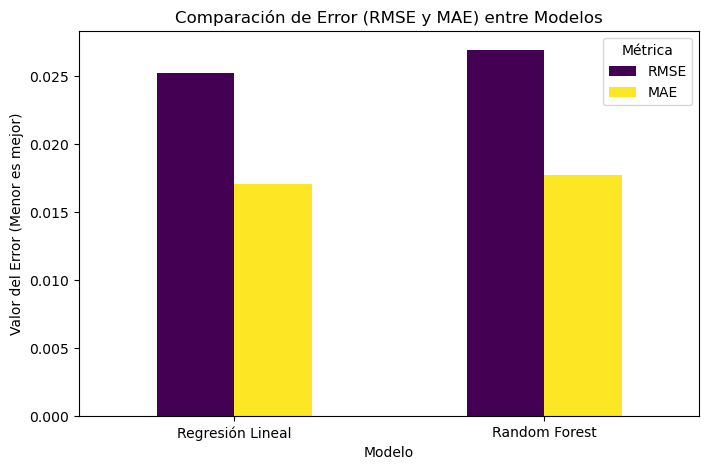

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Generar predicciones con ambos modelos
y_pred_lr = pipeline_regresion.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# 2. Función para calcular y mostrar métricas
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Métricas {nombre_modelo} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}\n")
    
    return {"Modelo": nombre_modelo, "RMSE": rmse, "MAE": mae, "R2": r2}

# Calculamos las métricas
metricas_lr = evaluar_modelo(y_test, y_pred_lr, "Regresión Lineal")
metricas_rf = evaluar_modelo(y_test, y_pred_rf, "Random Forest")

# 3. Visualización comparativa de RMSE y MAE
df_metricas = pd.DataFrame([metricas_lr, metricas_rf])

df_metricas.plot(x='Modelo', y=['RMSE', 'MAE'], kind='bar', figsize=(8, 5), colormap='viridis')
plt.title('Comparación de Error (RMSE y MAE) entre Modelos')
plt.ylabel('Valor del Error (Menor es mejor)')
plt.xticks(rotation=0)
plt.legend(title='Métrica')
plt.show()